In [1]:
import numpy as np
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd
import elevation 
import random
import copy
import datetime
import BORAS_v1
import itertools
import math
import cbor2
from astropy.time import Time

In [2]:
class path_info:
        def __init__(self,name,same,s_time):
            self.name = name
            self.same = same
            self.s_time = s_time

In [3]:
#PROBLEM DEFINITION
start_time_range = BORAS_v1.generate_time_range(11000.0, 11001.2, 0.027) #Range of time under study
#filename = "data/dems/plateau_2m_slope_1m_fixed.tif" #SLOPE MAP
filename = 'data/dems/test_case_B.tif'
#filename = 'data/dems/lunargem_4to5_2m_slope_1m.tif'
illumination_filename = 'data/illumination/test_case_B.cbor' #If TDD or GA
with rio.open(filename) as dataset:
        slope_dem = dataset.read(1) 
with open(illumination_filename, "rb") as file: #ILLUMINATION DICT
    roots = cbor2.load(file)
#waypoints = list([(53,53),(80,345),(234,253),(347,56),(125,190)])
#waypoints = list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049)]) #LUNARGEM RS1 Waypoint list
#waypoints = list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049),(2741, 1454)]) #LUNARGEM RS1 w/ WP3a Waypoint list
#waypoints = list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049),(2727,1797),(2649,2145)]) #LUNARGEM RS1 w/ WP5b&c Waypoint list
#waypoints= list([(2973, 784),(2793, 948),(2655, 1078),(2666, 1366),(2474, 1560),(2672, 1706),(2529, 2115),(2575, 2412),(2672, 2558),(2996, 2637),(3117, 3049),(2741, 1454),(2727,1797),(2649,2145)]) #LUNARGEM RS1 w/ WP5b&c Waypoint list
#waypoints = list([(50,350),(150,350),(140,266),(233,233),(168,168),(203,100),(345,75)])
#waypoints_d = [(5.340422, 18.696975),(5.334098, 18.691614), (5.329296,18.687256), (5.329713,18.677819),(5.322971,18.671367),(5.329852,18.666616),(5.324935,18.653105),(5.326486,18.643316),(5.329854,18.638515),(5.34129,18.63575),(5.345378,18.622315)]#,(5.332286,18.674938),(5.331758,18.663559),(5.329136,18.65205)]
#waypoints = BORAS_v1.coord_to_px(waypoints_d,dem)
start = (13,1)
end = (1,13)

In [4]:
old_path = []
info_paths = []
paths = [0]
same = 0
for time in start_time_range:
    start_time_str,formatted_path,total_time_str,pp = BORAS_v1.TDD_expanded(start,end,slope_dem,roots,[time,time+0.00001])
    if formatted_path != paths[-1]:
        paths.append(formatted_path)
    if old_path == formatted_path:
        same += 1
        path_idx = len(paths) - 2 - paths[::-1].index(formatted_path)
    else:
        same = 0
        path_idx = len(paths) - 2 - paths[::-1].index(formatted_path)
        print(path_idx)
        info_paths.append(path_info(path_idx,same,start_time_str))
    if info_paths[path_idx].same < same:
        info_paths[path_idx].same = same
    old_path = formatted_path

        


The Graph has been correctly generated
Optimal Departure Time: 11000.0
Path Taken: [(13, 1), (12, 1), (11, 1), (10, 1), (9, 2), (8, 3), (7, 4), (6, 4), (5, 4), (4, 5), (3, 6), (2, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
Total Traverse Time: 0.00934025329426469
0
The Graph has been correctly generated
Optimal Departure Time: 11000.027
Path Taken: [(13, 1), (12, 1), (11, 1), (10, 2), (9, 3), (8, 4), (7, 4), (6, 4), (5, 4), (4, 5), (3, 6), (2, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
Total Traverse Time: 0.009338378294264687
1
The Graph has been correctly generated
Optimal Departure Time: 11000.054
Path Taken: [(13, 1), (12, 1), (11, 1), (10, 1), (9, 2), (8, 3), (7, 4), (6, 4), (5, 4), (4, 5), (3, 6), (2, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13)]
Total Traverse Time: 0.009336503294264682
2
The Graph has been correctly generated
Optimal Departure Time: 11000.081
Path Taken: [(13, 1), (12, 1), (11, 1), (10, 1), (9, 2), (8, 3), (7, 4), (6, 4), (5,

In [5]:
max_same = 0
for i in range(len(paths)-1):
    same =  info_paths[i].same
    if same > max_same:
        max_same = same
        max_idx = i
print(max_idx)
print(max_same)
print(info_paths[max_idx].s_time)

14
17
11000.567


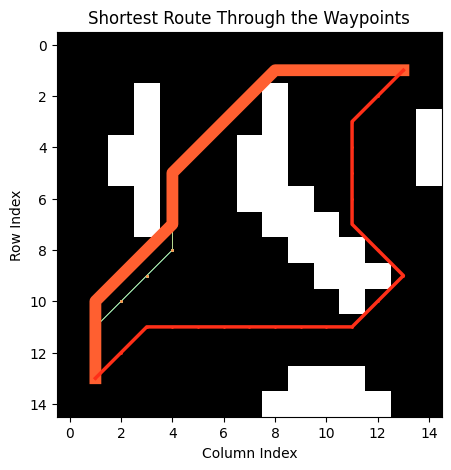

0.0


In [6]:
%matplotlib inline
import mpld3
import matplotlib.cm as cm
mpld3.disable_notebook()
dem = rio.open(filename)
slope_dem =dem.read(1)
color = iter(cm.rainbow(np.linspace(0, 1, len(paths))))
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')
total_trav_time = 0
for i in range(1,len(paths)):
    best_ga_path = paths[i]
    n =  info_paths[(i-1)].same
            # Extract x, y coordinates for path plotting
    path_x = [point[1] for point in best_ga_path]  # Col indices
    path_y = [point[0] for point in best_ga_path]  # Row indices
        # Plot path
    c = next(color)
    plt.plot(path_x, path_y, marker='o', color=c, markersize=1, linewidth=n/2)
    plt.title('Shortest Route Through the Waypoints')
    plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.grid(False)
plt.show()
print(total_trav_time/60)

In [7]:
for i in range (1,2):
    for i in range(len(paths)-1):
        same =  info_paths[i].same
        if same > max_same:
            max_same = same
            max_idx = i 
    pop.info_paths[max_idx].s_time

NameError: name 'pop' is not defined